In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
#open neutrino recoil sim root file
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7104868/sum_cevns_nb_recoils.root")
tree = file["Primary"]
tree5 = file["Hits"]

df = tree.arrays(library="pd")
df5 = tree5.arrays(library="pd")

#open neutron sim root file
file_neutron = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7104869/sum_neutron_planarsource.root")

tree_neutron = file_neutron["Primary"]
tree2_neutron = file_neutron["DetectorNeutrons"]
tree3_neutron = file_neutron["Hits"]

df_neutron = tree_neutron.arrays(library="pd")
df2_neutron = tree2_neutron.arrays(library="pd")
df3_neutron = tree3_neutron.arrays(library="pd")


In [3]:
#attempt to merge the primary energy here with the hits (one-to-one in events and energy deposition)
#the merging seems to do weird things that I don't want, why does it create 20 copies?
print(df)
#print(df5)
#test = df.merge(df5, on=["EventID"], how="inner")
#print(test)
#this is what I want if I have a one-to-one correspondence, doesn't quite work otherwise
merged_df5 = df.merge(df5, on=["EventID"], how="inner")
#print(merged_df5)
#internet solution, testing...
#merged_df5 = pd.DataFrame(merged_df5[merged_df5.index_x==merged_df5.index_y]['EventID'], columns=['EventID']).reset_index(drop=True)
#print(merged_df5)
merged_df5["ParticleName"] = merged_df5["ParticleName"].astype(str)

           EventID  TrackID       PDGCode  PrimaryEnergy  PrimaryPosX  \
0              0.0      1.0  1.000411e+09       0.130179     2.336131   
1              1.0      1.0  1.000411e+09       0.070677     6.964827   
2              2.0      1.0  1.000411e+09       0.111160   -14.412985   
3              3.0      1.0  1.000411e+09       0.080964     6.362458   
4              4.0      1.0  1.000411e+09       0.149884    14.166940   
...            ...      ...           ...            ...          ...   
7999995  7999995.0      1.0  1.000411e+09       0.033260     2.132456   
7999996  7999996.0      1.0  1.000411e+09       0.021294   -12.390989   
7999997  7999997.0      1.0  1.000411e+09       0.083251     4.064337   
7999998  7999998.0      1.0  1.000411e+09       0.003044   -12.508026   
7999999  7999999.0      1.0  1.000411e+09       0.117026     7.914925   

         PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0           8.003332   -15.452004          0.17267

In [4]:
#merge first on primary and detector neutrons, and then merge that with the individual nuclear recoils
print(df_neutron)
#actually how to merge when have smaller entries, need to start merge using inner join with the smaller dataframe and drop duplicates from the other one
merged_hits_neutrons = df3_neutron.merge(df_neutron.drop_duplicates(), on=["EventID"], how="inner")
#test something just to understand if this has limits
print(merged_hits_neutrons)
print(df3_neutron)
#merged_hits_neutrons = df_neutron.join(df3_neutron, on=["EventID"], how="inner", lsuffix="_x").reset_index(drop=True)

             EventID  TrackID  PDGCode  PrimaryEnergy  PrimaryPosX  \
0                0.0      1.0   2112.0      84.630926       -510.0   
1                1.0      1.0   2112.0     197.388788       -510.0   
2                2.0      1.0   2112.0     169.658930       -510.0   
3                3.0      1.0   2112.0      17.724100       -510.0   
4                4.0      1.0   2112.0      31.478058       -510.0   
...              ...      ...      ...            ...          ...   
10499995  11999995.0      1.0   2112.0     192.604748       -510.0   
10499996  11999996.0      1.0   2112.0     130.179986       -510.0   
10499997  11999997.0      1.0   2112.0      44.435014       -510.0   
10499998  11999998.0      1.0   2112.0     155.588848       -510.0   
10499999  11999999.0      1.0   2112.0     175.721636       -510.0   

          PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0          311.141576   165.149987          0.405475         -0.642969   
1          

In [5]:
#put dukecevns rate results (counts/keV/kg/SNS-year) into a histogram object
data_cevns = np.loadtxt("/N/project/phonon/jczettle/dukecevns-wdir/dukecevns-assumptions/out/sns_diff_rates_alliso-LiNbO-LiNbO-klein-150keV.out")
rec_energy = data_cevns[:,0]*1000.0
#convert to counts per keV
counts = data_cevns[:,1]/1000.0
bins_num = len(rec_energy)
counts_cevns, bin_edges = np.histogram(rec_energy, bins=bins_num, weights=counts)

print("Histogram values:", counts_cevns)
print("Bin edges:", bin_edges)

Histogram values: [12.5565    12.4401    12.3383    ...  0.0167993  0.0167875  0.0167756]
Bin edges: [1.00000000e-01 1.99933333e-01 2.99866667e-01 ... 1.49800133e+02
 1.49900067e+02 1.50000000e+02]


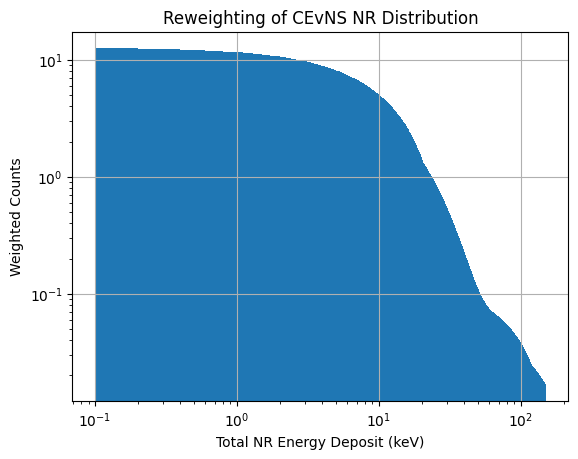

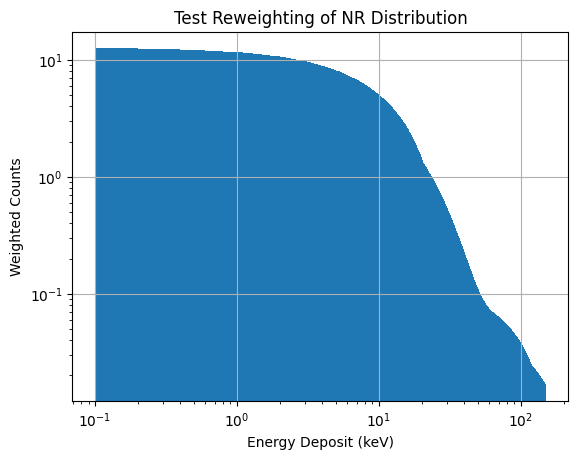

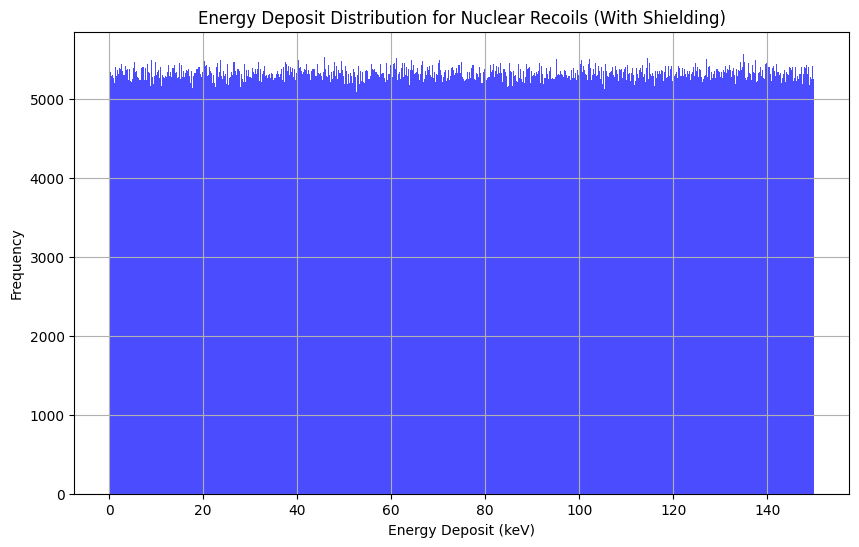

In [6]:
#build a weighted histogram based on the primary energy and the flux spectrum
def create_weights(counts_num, counts_den, edges, smooth=1e-12, clip=None, norm=""):
    denom = counts_den.astype(float)
    num = counts_num.astype(float)
    w = np.divide(num, denom, out=None, where=True)
    #w = np.divide(num, denom)
    if clip is not None:
        lo, hi = clip
        w = np.clip(w, lo, hi)
    if norm == "mean1":
        m = w.mean()
        if m > 0: w = w/m
    if norm == "sum1":
        s = w.sum()
        if s > 0: w = w/s
    return edges, w

def apply_weights(xs, edges, weights, underflow="extend", overflow="extend", default=1.0):
    xs = np.asarray(xs)
    idx = np.digitize(xs, edges, right=True) - 1 #creates a set from 0 to nbins-1
    nan_mask = ~np.isfinite(xs)
    idx = np.where(nan_mask, -1, idx)
    out = np.where(idx == -1, default, weights[idx])
    return out

#generate a histogram from the primary energies to apply the weights
Emin, Emax = rec_energy.min(), rec_energy.max()
counts_den, edges = np.histogram(df['PrimaryEnergy']*1000.0, bins=bins_num, range=(Emin, Emax))

#print("counts_cevns: ", counts_cevns) 
#print("counts_sim: ", counts_den)
#print("edges: " , edges)

#weight_vals = np.zeros_like(counts_den, dtype=float)
#nonzero = counts_den > 0
#weight_vals[nonzero] = 1.0/counts_den[nonzero]

#bin_idx = np.digitize(df['PrimaryEnergy'], edges, right=True) - 1
#event_weights = np.where((bin_idx >= 0 ) & (bin_idx < bins_num), weight_vals[bin_idx], 0.0)
#df["weight_vals"] = event_weights

#test_counts, edges = np.histogram(df['PrimaryEnergy'], bins=bins, range=(Emin, Emax), weights=df["weight_vals"])

fin_edges, weights = create_weights(counts_cevns, counts_den, edges)

#plt.hist(weights, bins=bins_num)
#plt.show()

#df["weight_vals"] = weights

df['weights'] = apply_weights(df['PrimaryEnergy']*1000.0, fin_edges, weights)
merged_df5['weights'] = apply_weights(merged_df5['PrimaryEnergy']*1000.0, fin_edges, weights)
#print(nr_merge_df)
#df2['weights'] = apply_weights(df2['PrimaryEnergy'], fin_edges, weights)
#print(df)
#print(df)

mask_total_test = df["totalNR"]*1000.0 > 0.1
mask_hit_test = merged_df5["Edep"]*1000.0 > 0.1

masked_df_total = df[mask_total_test]
masked_df_hit = merged_df5[mask_hit_test]

plt.hist(masked_df_total['totalNR']*1000.0, bins=bins_num, weights=masked_df_total['weights'])
plt.xlabel('Total NR Energy Deposit (keV)')
plt.ylabel('Weighted Counts')
plt.title('Reweighting of CEvNS NR Distribution')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig('CEvNS_Reweighted_test_spectrum.pdf')
plt.show()

plt.hist(masked_df_hit['totalNR']*1000.0, bins=bins_num, weights=masked_df_hit['weights'])
plt.xlabel('Energy Deposit (keV)')
plt.ylabel('Weighted Counts')
plt.title('Test Reweighting of NR Distribution')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.show()

#replicate original one as a sanity check
plt.figure(figsize=(10, 6))
plt.hist(masked_df_hit['totalNR']*1000.0, bins=bins_num, color='blue', alpha=0.7)
plt.title('Energy Deposit Distribution for Nuclear Recoils (With Shielding)')
plt.xlabel('Energy Deposit (keV)')
plt.ylabel('Frequency')
plt.grid()

plt.show()


In [7]:
#reweight on the neutrons by defining the power law, start with a area normalized version that I can scale by the actual flux value
#range is in MeV, flux value in something like n/MeV/m^2/us(spill) so I can normalize by the plane area and the time unit

def power_law(a, bins=100, rng=(0.01,200.0),density=False):
    lower_bound, upper_bound = float(rng[0]), float(rng[1])
    if upper_bound < lower_bound:
        raise ValueError("Upper bound must be greater than lower bound!")
    if isinstance(bins,int):
        edges = np.linspace(lower_bound, upper_bound, bins+1)
    else:
        edges = np.asarray(bins, dtype=float)
        if not np.all(np.diff(edges) > 0):
            raise ValueError("bin values must strictly increase!")
    widths = np.diff(edges)
    
    #compute the histogram
    pow_val = a + 1.0
    if lower_bound == 0 and a < -1:
        raise ValueError("cannot include lower_bound = 0 for a < -1 in this instance!")
    val_hi = edges[1:]**pow_val
    val_lo = edges[:-1]**pow_val
    denom = (upper_bound**pow_val) - (lower_bound**pow_val)
    prob = (val_hi - val_lo)/denom
    
    if density:
        hist = prob/widths
    else:
        hist = prob
    
            
    return hist, edges 

0.9999999999999996


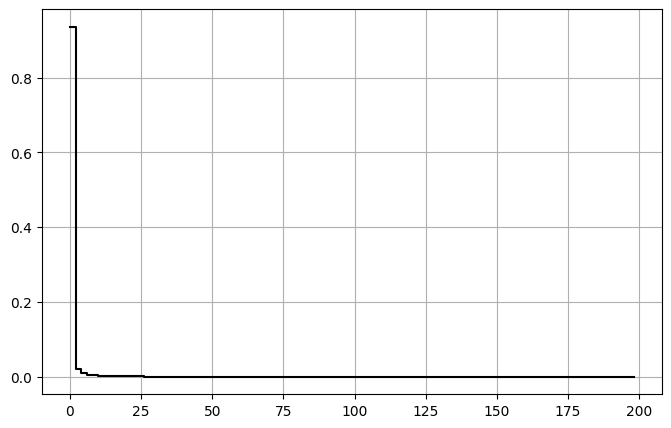

In [8]:
#generate normalized power law
h, e = power_law(-1.5)
#print(h)
print(np.sum(h))
#attempt a random scaling to check that as a concept, it works
#h = h * 1e3
plt.figure(figsize=(8,5))
plt.step(e[:-1], h, where="post", color="black")
plt.grid()
plt.show()

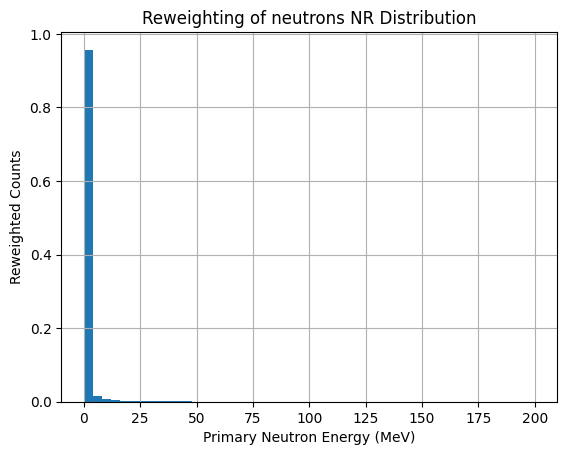

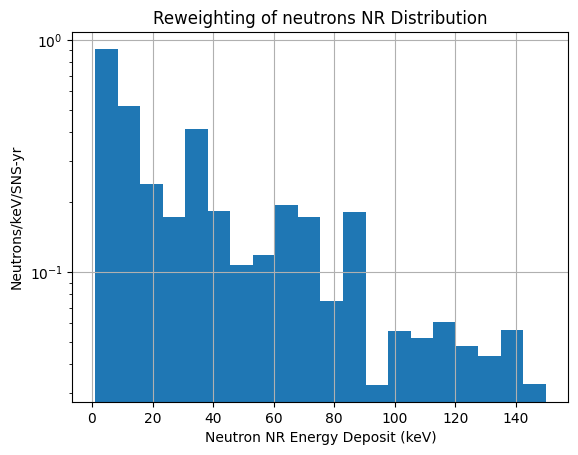

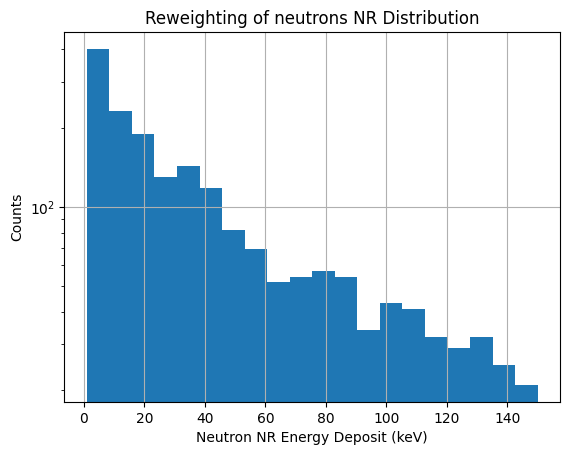

In [9]:
#with flux value from 2.5-40 MeV neutrons, restrict to that for now since we have defined flux
#mask_neutrons = (df_neutron['PrimaryEnergy'] > 2.5) & (df_neutron['PrimaryEnergy'] < 40.0)
#df_neutron_mask = df_neutron[mask_neutrons]

#now attempt a weighting with this using the original primaries
Emin, Emax = e.min(), e.max()
counts_den_neutron, edges_neutron = np.histogram(df_neutron['PrimaryEnergy'], bins=100, range=(Emin, Emax))
#generate weighting
fin_edges_neutron, weights_neutron = create_weights(h, counts_den_neutron, edges_neutron)

df_neutron['weights'] = apply_weights(df_neutron['PrimaryEnergy'], fin_edges_neutron, weights_neutron)
#merged_hits_neutrons['weights'] = apply_weights(merged_hits_neutrons['PrimaryEnergy'], fin_edges_neutron, weights_neutron)
#print(merged_hits_neutrons)
#this way works as I would expect, need to explore the merged dataframe better and understand that it is actually doing what I want
#with the stored weights it should be extendable to any variable that has the primary energy, might check that in each case common values give the same weight
plt.hist(df_neutron['PrimaryEnergy'], bins=50, range=(0.01, 200), weights=df_neutron['weights'])
plt.xlabel('Primary Neutron Energy (MeV)')
plt.ylabel('Reweighted Counts')
plt.title('Reweighting of neutrons NR Distribution')
#plt.yscale('log')
#plt.xscale('log')
plt.grid()
#plt.savefig('CEvNS_Reweighted_test_spectrum.pdf')
plt.show()

#mask = merged_hits_neutrons["totalNR"] > 0.0
#df_mask = merged_hits_neutrons[mask]

#scale the weights in order to get a full flux value
area = 1 #1 m^2 planar source
MWhr_per_yr = 7000 #assume 5000 hrs at 1.4 MW as in dukecevns calc
total_flux = 20 #in n/m^2/MWhr over the 2.5-40 MeV neutron energy range
df_neutron['weights'] = df_neutron['weights']*total_flux*area*MWhr_per_yr #convert to neutrons/SNS-year

#compute scale factor for /keV
bins_val = 20
lo, hi = 1, 150
width = (hi-lo)/(bins_val*1.0)
per_keV = width #convert to per keV

df_neutron['weights'] = df_neutron['weights']*per_keV

plt.hist(df_neutron['totalNR']*1000, bins=20, range=(1,150), weights=df_neutron['weights'])
plt.xlabel('Neutron NR Energy Deposit (keV)')
plt.ylabel('Neutrons/keV/SNS-yr')
plt.title('Reweighting of neutrons NR Distribution')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
#plt.savefig('CEvNS_Reweighted_test_spectrum.pdf')
plt.show()

plt.hist(df_neutron['totalNR']*1000, bins=20, range=(1,150))
plt.xlabel('Neutron NR Energy Deposit (keV)')
plt.ylabel('Counts')
plt.title('Reweighting of neutrons NR Distribution')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
#plt.savefig('CEvNS_Reweighted_test_spectrum.pdf')
plt.show()





/tmp/ipykernel_1944303/2370636457.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  masked_df_total['weights'] = masked_df_total['weights']*(per_keV/10.0) #scale to the bin width so it is still /keV and I retain the ~right integral


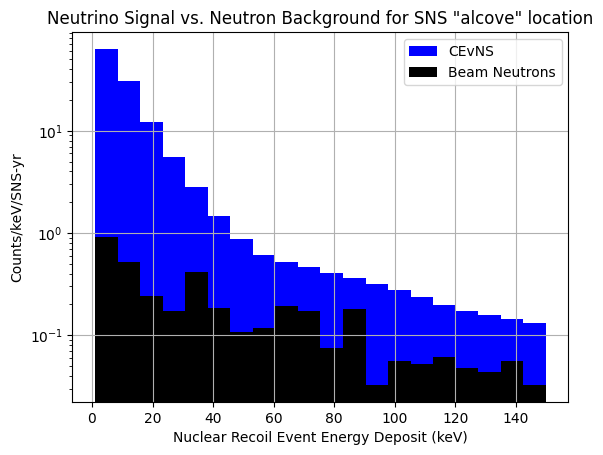

In [11]:
#plot both CEvNS and neutrons in the same plot with same binning scaling the binning for CEvNS too
masked_df_total['weights'] = masked_df_total['weights']*(per_keV/10.0) #scale to the bin width so it is still /keV and I retain the ~right integral
plt.hist(masked_df_total['totalNR']*1000.0, bins=20, range=(1,150), label="CEvNS", color='blue', weights=masked_df_total['weights'])
plt.hist(df_neutron['totalNR']*1000.0, bins=20, range=(1,150), label="Beam Neutrons", color='black', weights=df_neutron['weights'])
plt.xlabel('Nuclear Recoil Event Energy Deposit (keV)')
plt.ylabel('Counts/keV/SNS-yr')
plt.title('Neutrino Signal vs. Neutron Background for SNS "alcove" location')
plt.yscale('log')
plt.legend()
plt.grid()
plt.savefig('CEvNSNeutrons_AlcoveReweighting_FullNeutronSpectrum.pdf')
plt.show()